In [1]:
import torch
import torch.nn as nn

from torchvision.datasets import ImageFolder
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.transforms import v2

import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [3]:
transform = v2.Compose(
    [
        v2.ToImage(),
        v2.Grayscale(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Resize((224, 224)),
        v2.Normalize(mean=(0.5,), std=(0.5,))
    ]
)

In [4]:
DATA_PATH = '/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray'

full_train = ImageFolder(f'{DATA_PATH}/train', transform=transform)
test_data = ImageFolder(f'{DATA_PATH}/test', transform=transform)

In [5]:
print(f"Amount of Full Train Data: {len(full_train)}")
print(f"Classes: {full_train.classes}")
print(f"Amount of Test Data: {len(test_data)}")
print(f"Classes: {test_data.classes}")

Amount of Full Train Data: 5216
Classes: ['NORMAL', 'PNEUMONIA']
Amount of Test Data: 624
Classes: ['NORMAL', 'PNEUMONIA']


In [6]:
generator = torch.Generator().manual_seed(42)
train_data, val_data = random_split(full_train, [0.7, 0.3], generator=generator)

In [7]:
print(f"Amount of Train Data: {len(train_data)}")
print(f"Amount of Val Data: {len(val_data)}")

Amount of Train Data: 3652
Amount of Val Data: 1564


In [8]:
train_loader = DataLoader(dataset=train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(dataset=val_data, batch_size=32, shuffle=False)
test_loader = DataLoader(dataset=test_data, batch_size=32, shuffle=False)

In [9]:
images, labels = next(iter(train_loader))

print(images.shape)
print(images.dtype)
print(images.min(), images.max())
print(labels[:10])

torch.Size([32, 1, 224, 224])
torch.float32
tensor(-1.) tensor(0.9922)
tensor([0, 1, 1, 0, 0, 0, 1, 1, 1, 1])


In [10]:
class PneumoniaCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        self.act = nn.ReLU()

        self.fc1 = nn.Linear(128 * 28 * 28, 256)
        self.fc2 = nn.Linear(256, 2)

        self.flatten = nn.Flatten()

    def forward(self, x):
        x = self.pool(self.act(self.conv1(x)))
        x = self.pool(self.act(self.conv2(x)))
        x = self.pool(self.act(self.conv3(x)))
        x = self.flatten(x)
        x = self.act(self.fc1(x))
        x = self.fc2(x)
        return x

In [11]:
model = PneumoniaCNN().to(device)
model

PneumoniaCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (act): ReLU()
  (fc1): Linear(in_features=100352, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=2, bias=True)
  (flatten): Flatten(start_dim=1, end_dim=-1)
)

In [12]:
loss_model = nn.CrossEntropyLoss()
opt = torch.optim.Adam(model.parameters(), lr=0.001)

In [13]:
from tqdm.auto import tqdm

EPOCHS = 10
train_acc, train_loss = [], []
val_acc, val_loss = [], []

for epoch in range(EPOCHS):
    model.train()
    correct = 0
    running_loss = []

    train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} train", leave=False)
    for x, targets in train_loop:
        x, targets = x.to(device), targets.to(device)

        pred = model(x)
        loss = loss_model(pred, targets)

        opt.zero_grad()
        loss.backward()
        opt.step()

        running_loss.append(loss.item())
        correct += (pred.argmax(dim=1) == targets).sum().item()
        train_loop.set_postfix(loss=f"{sum(running_loss)/len(running_loss):.4f}")

    epoch_train_loss = sum(running_loss) / len(running_loss)
    epoch_train_acc = correct / len(train_data)
    train_loss.append(epoch_train_loss)
    train_acc.append(epoch_train_acc)

    model.eval()
    correct = 0
    running_loss = []

    with torch.no_grad():
        val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} val", leave=False)
        for x, targets in val_loop:
            x, targets = x.to(device), targets.to(device)

            pred = model(x)
            loss = loss_model(pred, targets)

            running_loss.append(loss.item())
            correct += (pred.argmax(dim=1) == targets).sum().item()

    epoch_val_loss = sum(running_loss) / len(running_loss)
    epoch_val_acc = correct / len(val_data)
    val_loss.append(epoch_val_loss)
    val_acc.append(epoch_val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"train loss {epoch_train_loss:.4f}, acc {epoch_train_acc:.4f} | "
          f"val loss {epoch_val_loss:.4f}, acc {epoch_val_acc:.4f}")

Epoch 1/10 train:   0%|          | 0/115 [00:00<?, ?it/s]

Epoch 1/10 val:   0%|          | 0/49 [00:00<?, ?it/s]

Epoch 1/10 | train loss 0.3093, acc 0.8842 | val loss 0.0930, acc 0.9674


Epoch 2/10 train:   0%|          | 0/115 [00:00<?, ?it/s]

Epoch 2/10 val:   0%|          | 0/49 [00:00<?, ?it/s]

...

Epoch 9/10 val:   0%|          | 0/49 [00:00<?, ?it/s]

Epoch 9/10 | train loss 0.0152, acc 0.9940 | val loss 0.0832, acc 0.9808


Epoch 10/10 train:   0%|          | 0/115 [00:00<?, ?it/s]

Epoch 10/10 val:   0%|          | 0/49 [00:00<?, ?it/s]

Epoch 10/10 | train loss 0.0111, acc 0.9956 | val loss 0.1065, acc 0.9642


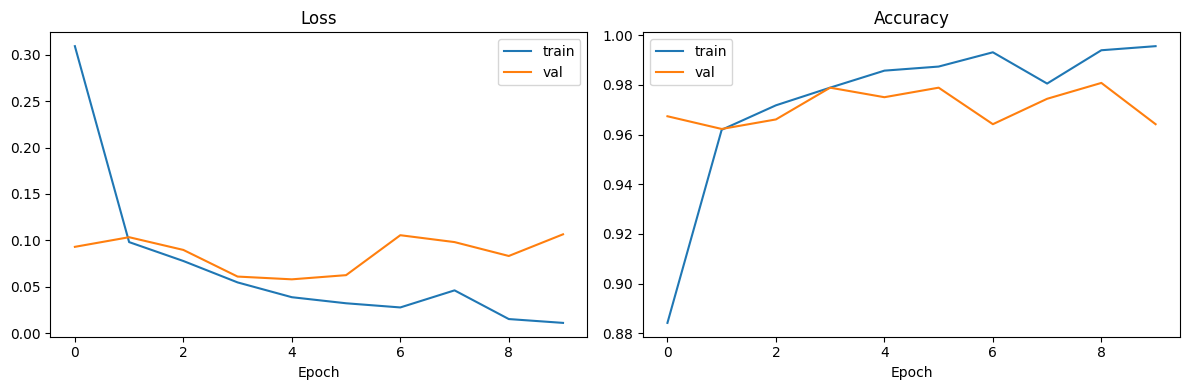

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_loss, label='train')
ax1.plot(val_loss, label='val')
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(train_acc, label='train')
ax2.plot(val_acc, label='val')
ax2.set_title('Accuracy')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()